📦 프로젝트 전체.  
├── 🏪 Track A: 매장 실행 플랜 (사장님께 바로 드릴 것).  
│   ├── 언제 어떤 쿠폰을 뿌릴지 (타이밍 + 타겟).  
│   ├── 인플루언서 $100 어떻게 써야 ROI 나오는지.  
│   └── 직원 레벨에서 바꿀 수 있는 운영 개선.  
│.  
└── 📮 Track B: 본사 제안서 (본사 마케팅팀에 올릴 것).  
    ├── BC주 데이터 기반 인사이트 요약.  
    ├── "이런 프로모션 BC에서 테스트해봤더니..." 근거 제시.  
    └── 본사가 전국 단위로 확장하면 좋을 제안.  


> 분석 → 제안 연결 구조
각 분석이 어느 Track으로 가는지 미리 매핑해두면 흔들리지 않아요.


분석 항목나올 수 있는 인사이트연결되는 Track시간대별 매출"목요일 저녁 슬럼프" 발견A: 해당 요일 쿠폰 집중 배포메뉴별 판매량"카라아게 사이드 같이 주문율 높음"A: 업셀 스크립트 / B: 세트메뉴 제안지점별 성과 차이"코퀴틀람 지점이 객단가 높음"B: 코퀴틀람 방식 BC 전체 적용 제안계절별 트렌드"여름에 냉라멘류 급증"B: 시즌 메뉴 기획 제안인플루언서 협업 전후방문객 or 매출 변화A: 어떤 콘텐츠/타이밍이 효과적인지

포트폴리오 관점에서 추가로 챙길 것
이 프로젝트가 특별한 이유를 README나 소개글에 꼭 써야 해요.

"단순 분석이 아니라, 프랜차이즈 구조 안에서 매장 오너가 실제로 실행 가능한 범위를 파악하고, Track A(즉시 실행)와 Track B(본사 제안)로 분리해서 제안했다"

이게 취업 포트폴리오나 클라이언트 포트폴리오 둘 다에서 먹히는 포인트예요.

# **1. Load and integrate data**

In [1]:
from google.colab import drive
import pandas as pd
import os
import glob

drive.mount('/content/drive')

# import raw dataset
load_path = '/content/drive/MyDrive/KintonRamen/Kinton_raw_data/Kinton_Refined_Data(2025.06-2026.04)/kinton_all_merged(BC_11_branches,2025.06-2026.04).parquet'
df_total = pd.read_parquet(load_path)

print(f"Raw Dataset: total {len(df_total):,} rows")

Mounted at /content/drive
Raw Dataset: total 3,519,521 rows


## **1-1. Data Preparation & Consolidation**
This dataset (`df_total`) was created by merging line transaction files from 11 British Columbia (BC) locations into a single consolidated dataset.

* **Data Source:** `Lightspeed(K-series)` → `Reports` → `All Reports` → `Order Reports` → `Line Transactions`
    * **Coverage:** June 11, 2025 (Official Lightspeed launch) – April 12, 2026
    * **Note:** Some stores have shorter data periods due to their respective opening dates:
        * **Broadway:** From Dec 11, 2025
        * **Gilmore:** From Dec 24, 2025
        * **Coquitlam:** From Feb 10, 2026
        * **UVic:** From Mar 8, 2026

* **Preprocessing Steps:**
    * Combined individual store files into a unified dataset.
    * **Added Columns:**
        * `Store_Name`: Official store name.
        * `Data_Period`: The specific timeframe for each record.
        * `Year_Folder`: Categorized by source folder (2025 or 2026).

* **Storage Optimization:**
    * The merged dataset contains approximately **2.2 million rows**.
    * To optimize mount/loading performance and reduce I/O overhead, the file was saved in **Parquet format**.

In [2]:
# Sort by data size
print(df_total.groupby(['Store_Name', 'Year_Folder']).size().sort_values(ascending=False).reset_index(name='count'))

                     Store_Name Year_Folder   count
0                  vancouverubc        2025  386653
1   victoriadowntownwharfstreet        2025  344902
2        vancouvermarinegateway        2025  333702
3               vancouverrobson        2025  324862
4           surreykinggeorgehub        2025  321611
5                  vancouverubc        2026  223089
6               kelownadowntown        2025  220446
7       vancouvernorthvancouver        2025  207613
8           surreykinggeorgehub        2026  172703
9               vancouverrobson        2026  165010
10       vancouvermarinegateway        2026  164163
11  victoriadowntownwharfstreet        2026  126311
12      vancouvernorthvancouver        2026  123997
13              kelownadowntown        2026  119833
14            vancouverbroadway        2026   97231
15               burnabygilmore        2026   77055
16       coquitlamsunwoodsquare        2026   57285
17    victoriauniversityheights        2026   32358
18          

*데이터 사이즈 순으로 매장을 나열했지만, noise를 cleaning 하지 않은 단순 데이터 사이즈이므로 참고만 바랍니다.

In [3]:
print(df_total.head())

  Identifier      PeriodId           YearId      Device_Name   Passive_Device  \
0  S992095.1  SP992095.1.1  SY992095.2025.1  iPad164(992095)  iPad187(992119)   
1  S992095.2  SP992095.1.2  SY992095.2025.2  iPad164(992095)  iPad187(992119)   
2  S992095.3  SP992095.1.3  SY992095.2025.3  iPad164(992095)  iPad187(992119)   
3  S992095.4  SP992095.1.4  SY992095.2025.4  iPad164(992095)  iPad187(992119)   
4  S992095.5  SP992095.1.5  SY992095.2025.5  iPad164(992095)  iPad187(992119)   

                Date  Mode    Account         AccountName           Staff  \
0  11/06/25 10:01 AM  Prod  A992095.1  Dine-In, Table 101  Server(789135)   
1  11/06/25 10:01 AM  Prod  A992095.1  Dine-In, Table 101  Server(789135)   
2  11/06/25 10:01 AM  Prod  A992095.1  Dine-In, Table 101  Server(789135)   
3  11/06/25 10:03 AM  Prod  A992095.1  Dine-In, Table 101  Server(789135)   
4  11/06/25 10:03 AM  Prod  A992095.1  Dine-In, Table 101  Server(789135)   

   ...                   Group StatGroup  TaxName 

In [4]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3519521 entries, 0 to 3519520
Data columns (total 31 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Identifier      object 
 1   PeriodId        object 
 2   YearId          object 
 3   Device_Name     object 
 4   Passive_Device  object 
 5   Date            object 
 6   Mode            object 
 7   Account         object 
 8   AccountName     object 
 9   Staff           object 
 10  Reference       object 
 11  Type            object 
 12  Qty             float64
 13  UnitPrice       float64
 14  FinalPrice      float64
 15  Discount        float64
 16  Loss            float64
 17  Comp            float64
 18  Charge          float64
 19  SKU             object 
 20  Item            object 
 21  Group           object 
 22  StatGroup       object 
 23  TaxName         object 
 24  TaxRate         float64
 25  PreTax          float64
 26  TaxAmount       float64
 27  Profile         object 
 28  Store_Name  

### **Master Dataset's Column Definitions (Before Cleaning)**

| # | Column | Description |
|:---|:---|:---|
| 0 | **Identifier** | Unique ID for each transaction line |
| 1 | **PeriodId** | Accounting period identifier |
| 2 | **YearId** | Fiscal year and cycle ID |
| 3 | **Device_Name** | Main ordering device (iPad) |
| 4 | **Passive_Device** | Secondary/Passive device name |
| 5 | **Date** | Date and time of the transaction |
| 6 | **Mode** | Operation mode (e.g., Prod) |
| 7 | **Account** | Unique order or check number |
| 8 | **AccountName** | Table number or customer name |
| 9 | **Staff** | Staff or system that processed the order |
| 10 | **Reference** | Transaction reference number |
| 11 | **Type** | Transaction type (e.g., SALE) |
| 12 | **Qty** | Item quantity |
| 13 | **UnitPrice** | Price per unit |
| 14 | **FinalPrice** | Total price after adjustments |
| 15 | **Discount** | Applied discount amount |
| 16 | **Loss** | Recorded loss amount |
| 17 | **Comp** | Complimentary/Free item amount |
| 18 | **Charge** | Extra service charges |
| 19 | **SKU** | Product stock keeping unit |
| 20 | **Item** | Name of the menu item |
| 21 | **Group** | Menu category group |
| 22 | **StatGroup** | Statistical reporting group |
| 23 | **TaxName** | Type of tax applied |
| 24 | **TaxRate** | Tax percentage rate |
| 25 | **PreTax** | Amount before tax |
| 26 | **TaxAmount** | Calculated tax amount |
| 27 | **Profile** | Order channel (Dine-in/Delivery) |
| 28 | **Store_Name** | Name of the store location |
| 29 | **Data_Period** | Total data collection period |
| 30 | **Year_Folder** | Source folder indicator (2025 or 2026) |

### Columns Definition (이건 나중에 다시써먹기) 여기 꺼 아님)

| Column | Description |
|:---|:---|
| Identifier | Unique ID for each transaction line |
| PeriodId | Accounting period identifier |
| YearId | Fiscal year and cycle ID |
| Device_Name | Main ordering device (iPad) |
| Passive_Device | Secondary/Passive device name |
| transaction_date | Date and time of transaction |
| Mode | Operation mode (e.g., Prod) |
| Account | Unique order or check number |
| AccountName | Table number or customer name |
| Staff | Staff or system that processed the order |
| Reference | Transaction reference number |
| Type | Transaction type (e.g., SALE) |
| Qty | Item quantity |
| UnitPrice | Price per unit |
| FinalPrice | Total price after adjustments |
| Discount | Applied discount amount |
| Loss | Recorded loss amount |
| Comp | Complimentary/Free item amount |
| Charge | Extra service charges |
| SKU | Product stock keeping unit |
| Item | Name of the menu item |
| Group | Menu category group |
| StatGroup | Statistical reporting group |
| TaxName | Type of tax applied |
| TaxRate | Tax percentage rate |
| PreTax | Amount before tax |
| TaxAmount | Calculated tax amount |
| Profile | Order channel (Dine-in/Delivery) |
| Store_Name | Name of the store location |
| Data_Period | Total data collection period |
| year | Extracted year |
| date | Extracted date (YYYY-MM-DD) |
| hour | Hour of transaction |
| weekday_name | Day of the week |
| is_weekend | Weekend indicator (True/False) |

In [5]:
round(df_total.describe(),2)

,Qty,UnitPrice,FinalPrice,Discount,Loss,Comp,Charge,TaxRate,PreTax,TaxAmount
count,3519521.00,3519521.00,3519521.00,3519521.00,3519521.0,3519521.00,3519521.0,3519219.00,3519219.00,3519219.00
mean,0.72,4.96,3.62,0.01,0.0,0.04,0.0,1.06,3.62,0.19
std,1.68,9.73,10.08,0.32,0.0,0.83,0.0,0.02,10.08,0.51
min,-454.00,-167.94,-2719.46,-27.30,0.0,-83.99,0.0,1.00,-2719.46,-135.97
25%,1.00,0.00,0.00,0.00,0.0,0.00,0.0,1.05,0.00,0.00
50%,1.00,0.00,0.00,0.00,0.0,0.00,0.0,1.05,0.00,0.00
75%,1.00,6.99,3.40,0.00,0.0,0.00,0.0,1.05,3.40,0.25
max,2000.00,800.00,2719.46,29.97,0.0,200.00,0.0,1.15,2719.46,135.97


In [6]:
# Shape of the dataset
print(f"The number of rows: {df_total.shape[0]}")
print(f"The number of columns: {df_total.shape[1]}")

# Menu Category
print(f"\nCategory: {df_total['Group'].unique()}")


The number of rows: 3519521
The number of columns: 31

Category: ['Ramen(777328951034371)' 'Toppings(777328951037512)'
 'Drinks - NA(777328951034297)' 'Tapas(777328951034588)'
 'Drinks - NA Sugar(777328951034302)' 'Merchandise(777328951037790)'
 'Deliverect(777328951034158)' 'Misc(777328951037792)'
 'Desserts(777328951034219)' 'Drinks - Alcohol(777328951034240)'
 'Gift Cards(777328951033894)' 'Fees(777328951038017)']


# **2. Data Cleaning**

## Data Cleaning & Preparation Strategy

This consolidated dataset captures a wide range of business insights, including **products sold, pricing, payment methods, and precise timestamps** for each transaction across all 11 locations.

To transform this rich raw data into clear, actionable reports, I will implement the following cleaning steps:

* **Standardizing Formats:** Ensure all dates and numbers are in the correct format for accurate calculations and time-series trends.
* **Removing Unnecessary Columns:** Delete irrelevant columns to streamline the dataset and focus only on key business metrics.
* **Handling Missing Data:** Review any empty fields and either fill them or exclude them to ensure the final results are not misleading.
* **Breaking Down Combined Data:** Split columns that contain multiple pieces of information into separate, clear fields for better grouping and analysis.
* **Filtering Out Non-Sales Records:** Remove administrative notes and miscellaneous entries to isolate and focus strictly on actual sales transactions.

## **2-1. Change branch name**

> Official store name is too long, so to enhance analytical efficiency, I have simplified the official store names as follows:

| Official Store Name | Alias (Simplified) |
|:---|:---|
| burnaby gilmore | Gilmore |
| coquitlam sunwoodsquare | Coquitlam |
| kelowna downtown | KelownaDT |
| surrey kinggeorgehub | KingGeorge |
| vancouver broadway | Broadway |
| vancouver marinegateway | MarineGate |
| vancouver northvancouver | NorthVan |
| vancouver robson | Robson |
| vancouver ubc | UBC |
| victoria downtownwharfstreet | VictoriaDT |
| victoria universityheights | UVic |

In [7]:
# Change the store names
name_map = {
    'burnabygilmore': 'Gilmore',
    'coquitlamsunwoodsquare': 'Coquitlam',
    'kelownadowntown': 'KelownaDT',
    'surreykinggeorgehub': 'KingGeorge',
    'vancouverbroadway': 'Broadway',
    'vancouvermarinegateway': 'MarineGate',
    'vancouvernorthvancouver': 'NorthVan',
    'vancouverrobson':'Robson',
    'vancouverubc':'UBC',
    'victoriadowntownwharfstreet':'VictoriaDT',
    'victoriauniversityheights':'UVic'
}

df_total['Store_Name'] = df_total['Store_Name'].replace(name_map)

print(df_total['Store_Name'].unique())

['KelownaDT' 'KingGeorge' 'Broadway' 'Gilmore' 'MarineGate' 'NorthVan'
 'Robson' 'UBC' 'VictoriaDT' 'Coquitlam' 'UVic']


## **2-2. Date type transformation**

In [8]:
# Convert 'Date' column to datetime and rename columns
df_total = df_total.rename(columns={'Date': 'transaction_date', 'Year_Folder':'year'})
df_total['transaction_date'] = pd.to_datetime(df_total['transaction_date'], format='%d/%m/%y %I:%M %p')

# Exclude Pre-launch Test Data (2026.06.10, UBC)
# Filtering out test records to ensure the dataset only reflects official operations starting from June 11, 2025.
df_total = df_total[df_total['transaction_date'] >= '2025-06-11']

# Extract date and time components
df_total['date'] = df_total['transaction_date'].dt.date
df_total['date'] = pd.to_datetime(df_total['date'])
df_total['hour'] = df_total['transaction_date'].dt.hour
df_total['weekday_name'] = df_total['transaction_date'].dt.strftime('%a')
df_total['is_weekend'] = df_total['transaction_date'].dt.dayofweek.isin([5, 6])
df_total['year'] = df_total['year'].astype(int)

# Check
print(df_total[['transaction_date','year', 'date', 'hour', 'weekday_name', 'is_weekend']].head(3))
print("--------------------------")

# Checking the dataset period
start_date = df_total['transaction_date'].min()
end_date = df_total['transaction_date'].max()

print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")

     transaction_date  year       date  hour weekday_name  is_weekend
0 2025-06-11 10:01:00  2025 2025-06-11    10          Wed       False
1 2025-06-11 10:01:00  2025 2025-06-11    10          Wed       False
2 2025-06-11 10:01:00  2025 2025-06-11    10          Wed       False
--------------------------
Start Date: 2025-06-11 10:01:00
End Date: 2026-04-20 17:47:00


## **2-3. Drop columns**

>Before dropping any columns, I will inspect the entire dataset to identify which columns are unnecessary for the analysis.

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_total.head(10))

   Identifier       PeriodId            YearId      Device_Name  \
0   S992095.1   SP992095.1.1   SY992095.2025.1  iPad164(992095)   
1   S992095.2   SP992095.1.2   SY992095.2025.2  iPad164(992095)   
2   S992095.3   SP992095.1.3   SY992095.2025.3  iPad164(992095)   
3   S992095.4   SP992095.1.4   SY992095.2025.4  iPad164(992095)   
4   S992095.5   SP992095.1.5   SY992095.2025.5  iPad164(992095)   
5   S992095.6   SP992095.1.6   SY992095.2025.6  iPad164(992095)   
6   S992095.7   SP992095.1.7   SY992095.2025.7  iPad164(992095)   
7   S992095.8   SP992095.1.8   SY992095.2025.8  iPad164(992095)   
8   S992095.9   SP992095.1.9   SY992095.2025.9  iPad164(992095)   
9  S992095.10  SP992095.1.10  SY992095.2025.10  iPad164(992095)   

    Passive_Device    transaction_date  Mode    Account         AccountName  \
0  iPad187(992119) 2025-06-11 10:01:00  Prod  A992095.1  Dine-In, Table 101   
1  iPad187(992119) 2025-06-11 10:01:00  Prod  A992095.1  Dine-In, Table 101   
2  iPad187(992119) 2025-0

Some columns are not needed for analysis and have been dropped to reduce memory usage:

- **PeriodId**: Internal system sequence ID, no analytical value
- **YearId**: Redundant with the `year` column already extracted from `transaction_date`
- **Device_Name**: iPad terminal identifier, store-level tracking done via `Store_Name`
- **Passive_Device**: Secondary device ID, no analytical value
- **Mode**: Single-value column (all 'Prod'), no variance to analyze
- **StatGroup**: Empty column (all '[]'), no analytical value
- **Data_Period**: Redundant with `year` and `date` columns
- **TaxName**: Tax category label, not needed for revenue analysis
- **TaxRate**: Tax rate constant, not needed when `PreTax` is available
- **TaxAmount**: Derivable from `PreTax`, redundant for analysis

In [10]:
# drop some columns
drop_cols = ['PeriodId', 'YearId', 'Device_Name', 'Passive_Device', 'Mode', 'StatGroup', 'Data_Period', 'TaxName', 'TaxRate', 'TaxAmount']
df_total = df_total.drop(columns=drop_cols)

In [11]:
# check the fianl data type of dataset
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3518134 entries, 0 to 3519520
Data columns (total 25 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Identifier        object        
 1   transaction_date  datetime64[ns]
 2   Account           object        
 3   AccountName       object        
 4   Staff             object        
 5   Reference         object        
 6   Type              object        
 7   Qty               float64       
 8   UnitPrice         float64       
 9   FinalPrice        float64       
 10  Discount          float64       
 11  Loss              float64       
 12  Comp              float64       
 13  Charge            float64       
 14  SKU               object        
 15  Item              object        
 16  Group             object        
 17  PreTax            float64       
 18  Profile           object        
 19  Store_Name        object        
 20  year              int64         
 21  date         

## **2-4. Handling Missing Values**

In [12]:
# check null values
print(df_total.isnull().sum())
print()
print(df_total.isnull().sum() / len(df_total) * 100)  # ratio

Identifier             0
transaction_date       0
Account                0
AccountName         3891
Staff                  0
Reference              0
Type                   0
Qty                    0
UnitPrice              0
FinalPrice             0
Discount               0
Loss                   0
Comp                   0
Charge                 0
SKU                    0
Item                   0
Group                  0
PreTax               302
Profile             5518
Store_Name             0
year                   0
date                   0
hour                   0
weekday_name           0
is_weekend             0
dtype: int64

Identifier          0.000000
transaction_date    0.000000
Account             0.000000
AccountName         0.110598
Staff               0.000000
Reference           0.000000
Type                0.000000
Qty                 0.000000
UnitPrice           0.000000
FinalPrice          0.000000
Discount            0.000000
Loss                0.000000
Comp         

### 📌 Missing Values

The percentage of missing values across the 2.2 million rows is minimal. To prevent data bias and ensure consistency, I applied the following imputation strategies:

* **AccountName (0.11%)**: These were identified as missing entries from POS terminals and replaced with `'Unknown'`.
* **PreTax (0.008%)**: Missing values were adjusted based on the `FinalPrice` of the same row to maintain data integrity.
* **Profile (0.15%)**: Reclassified complex profile labels and missing values into four standardized categories: Dine-in, Delivery, Takeaway, and Unknown. This new channel feature enables a more streamlined analysis of order distribution and revenue streams.

In [13]:
print("AccountName: ",df_total['AccountName'].unique())
print("Profile: ", df_total['Profile'].unique())

Profile:  ['Dine-in' 'Takeaway' None 'Happy Hour' 'DoorDash Delivery'
 'UberEats Delivery' 'DoorDash Takeaway' 'Skip Delivery' 'Skip Takeaway'
 'UberEats Takeaway' 'Delivery' 'Fantuan Takeaway' 'Fantuan Delivery'
 'Ritual Takeaway' 'Smooth Takeaway' 'Smooth Delivery' 'API '
 'Ritual Delivery']
AccountName:  ['Dine-In, Table 101' 'Dine-In, Table C1' 'Dine-In, Table T1' ...
 'SHIVAM S.' 'riri ..' 'Erina C.']


1. Account Name: 테이블 네임, 배달의 경우 고객이름
2. Profile: Dine-in, Takeaway, Happy hour, Delivery 종류? 이름

In [14]:
# 1. AccountName: Unknown
df_total['AccountName'] = df_total['AccountName'].fillna('Unknown')

# 2. PreTax: Adjusted based on the 'FinalPrice'
df_total['PreTax'] = df_total['PreTax'].fillna(df_total['FinalPrice'])

# 3. Profile → Create 'channel' column
def categorize_profile(profile):
    if pd.isna(profile):
        return 'Unknown'
    p = str(profile).strip().lower()
    if 'dine' in p or 'happy hour' in p:
        return 'Dine-in'
    elif 'delivery' in p:
        return 'Delivery'
    elif any(x in p for x in ['takeaway', 'takeout', 'ritual', 'api']):
        return 'Takeaway'
    else:
        return 'Unknown'

df_total['channel'] = df_total['Profile'].apply(categorize_profile)
print(df_total['channel'].value_counts())

channel
Dine-in     2785562
Delivery     487218
Takeaway     239836
Unknown        5518
Name: count, dtype: int64


## **2-5. Change some columns**

In [15]:
# Type 컬럼 unique 확인 (SALE 외에 뭐가 있는지)
print(df_total['Type'].value_counts())
print("------------------------------")
# FinalPrice 음수 행 확인
print(df_total[df_total['FinalPrice'] < 0].shape[0])
print(df_total[df_total['FinalPrice'] < 0]['Item'].value_counts().head(20))

Type
SALE               2693655
TRANSFER            310335
SPLIT               283989
UPDATE               71159
TRANSITORY_COMP      41116
TRANSITORY_OPEN      41100
VOID                 35292
FOREIGN              28109
RECALL               13275
REFUND                 104
Name: count, dtype: int64
------------------------------
243184
Item
UberEats Discount                  25947
Topping - $Egg                     21602
Doordash Discount                  12191
Ramen - Pork Spicy Garlic          10632
Combo - Value Meals                10632
Ramen - Pork Original              10428
Combo - Meal for One                8821
Ramen - Beef Original               6601
Ramen - Beef Spicy Garlic           5815
Tapas - Age Gyoza (Pork)            5809
Combo - Meal for Two                5112
Ramen - Pork Miso                   4864
Ramen - Chicken Spicy Garlic        3869
Ramen - Chicken Original            3578
Ramen - Veggie Spicy Garlic         3433
Tapas - Takoyaki                    3389


1. Type Column:
  - Sale: Actual Sale
  - Transfer: Which is transfered from another table
  - Split: Split bill from one table


In [16]:
# Type별로 FinalPrice 분포 확인
print(df_total.groupby('Type')['FinalPrice'].describe())

# 음수인 행의 Type 분포
print(df_total[df_total['FinalPrice'] < 0]['Type'].value_counts())

                     count      mean        std      min    25%   50%    75%  \
Type                                                                           
FOREIGN            28109.0  3.899180   7.671624    -8.49   0.00  0.00   3.50   
RECALL             13275.0  5.875421   9.629723   -34.98   0.00  1.00  10.99   
REFUND               104.0 -4.904519   7.750325   -40.00  -6.24 -0.25   0.00   
SALE             2693655.0  4.901421   9.751657  -167.94   0.00  0.00   6.99   
SPLIT             283989.0  4.304837   7.589239    -2.00   0.00  0.00   3.99   
TRANSFER          310335.0 -4.271763   7.590027  -200.00  -3.99  0.00   0.00   
TRANSITORY_COMP    41116.0 -6.455799  12.256880   -83.99 -18.99 -2.49   0.00   
TRANSITORY_OPEN    41100.0  6.456069  12.256951   -57.96   0.00  2.49  18.99   
UPDATE             71159.0 -4.877291   8.179235  -100.00  -6.99  0.00   0.00   
VOID               35292.0 -5.338681  17.443969 -2719.46  -6.99  0.00   0.00   

                     max  
Type        

In [17]:
print(df_total[df_total['Type'] == 'RECALL'][['AccountName','Type','FinalPrice','Item']].head(10))
print()
print(df_total[df_total['Type'] == 'FOREIGN'][['AccountName','Type','FinalPrice','Item']].head(10))

            AccountName    Type  FinalPrice                        Item
107   Dine-In, Table C1  RECALL        0.25                   Paper Bag
5645  Dine-In, Table W5  RECALL        0.00                       Ramen
5646  Dine-In, Table W5  RECALL       18.99    Ramen - Yuzu Chill Ramen
5647  Dine-In, Table W5  RECALL        0.00              Noodles - Thin
5648  Dine-In, Table W5  RECALL        5.99             Tapas - Edamame
5649  Dine-In, Table W5  RECALL        6.99     Tapas - Age Gyoza (Veg)
5650  Dine-In, Table W5  RECALL        0.00                       Ramen
5651  Dine-In, Table W5  RECALL       15.99       Ramen - Chicken Shoyu
5652  Dine-In, Table W5  RECALL        0.00              Noodles - Thin
5653  Dine-In, Table W5  RECALL       10.99  Tapas - Hot Karaage (3 PC)

    AccountName     Type  FinalPrice                      Item
605  Table T6.2  FOREIGN        0.00                     Ramen
607  Table T6.2  FOREIGN        4.24         Ramen - Pork Miso
609  Table T6.2  F

In [18]:
# Keep only actual sales rows
valid_types = ['SALE', 'SPLIT']
df_clean = df_total[df_total['Type'].isin(valid_types)].copy()

print(f"Total: {len(df_total):,} rows")
print(f"After filtering: {len(df_clean):,} rows")
print(f"Removed Rows: {len(df_total) - len(df_clean):,} rows")

Total: 3,518,134 rows
After filtering: 2,977,644 rows
Removed Rows: 540,490 rows


## 2-5. Group column

Group columns has numeric ID with item name. (e.g., Tapas(777328951034588), Ramen(777328951034371)) I'll remove this numeric ID for analysis efficiency.

In [19]:
df_clean['category'] = df_clean['Group'].astype(str).str.split('(').str[0].str.strip()
print(df_clean['category'].unique())

['Ramen' 'Toppings' 'Drinks - NA' 'Tapas' 'Drinks - NA Sugar'
 'Merchandise' 'Deliverect' 'Misc' 'Desserts' 'Drinks - Alcohol'
 'Gift Cards' 'Fees']


Further more, we have some unclear values from the Group column.
- Misc: It means Order note, Item Note. Usually it's used for specific order asked from customer so I'll remove this data.
- Deliverect: Delivery Apps(Uber Eats, DoorDash, Skip etc) discount information. e.g., Bogo event
- Merchandise: e.g., Anniversary Tee
- Fee: Paper Bag / Delivery fee from UEAT(Kinton Ramen's website order)

In [20]:
# Remove Misc
remove_categories = ['Misc']
df_clean = df_clean[~df_clean['category'].isin(remove_categories)].copy()

print(f"After removing: {len(df_clean):,} rows")
print(df_clean['category'].value_counts())

After removing: 2,926,845 rows
category
Ramen                1868485
Tapas                 350791
Drinks - NA Sugar     268567
Toppings              264723
Drinks - Alcohol       44024
Desserts               38632
Deliverect             36577
Drinks - NA            36352
Fees                   17235
Merchandise              793
Gift Cards               666
Name: count, dtype: int64


In [21]:
print(df_clean[df_clean['Group'].str.contains('Deliverect', na=False)][['SKU','Item','FinalPrice','channel']].value_counts(['SKU','Item']).head(30))

SKU   Item                      
UE99  UberEats Discount             24229
DD99  Doordash Discount             11047
SK99  SkipTheDishes Discount Fee     1120
SM77  Smooth Delivery Fee              62
FT99  Fantuan Discount                 55
SM99  Smooth Discount Fee              43
SM66  Smooth Service Charge            21
Name: count, dtype: int64


## **2-6. Checking BOGO SKU**

To enhence the analysis quality, I'll check the BOGO menus and SKU names.

In [22]:
# Checking the item which has 'BOGO' in SKU name
bogo_df = df_clean[df_clean['SKU'].str.contains('-BOGO_', na=False)]

bogo_items = bogo_df['Item'].unique()

# Print
print("BOGO items:")
print(bogo_items)
print(f"\nThere are {len(bogo_items)} BOGO items in total.")

BOGO items:
['Ramen BOGO - Burnt Shoyu' 'Combo - Cheesecake (BOGO)'
 'Tapas - Takoyaki (BOGO)' 'Ramen BOGO - Veggie Immune Booster'
 'Ramen BOGO - Summer Harvest Ramen' 'Ramen BOGO - Chicken Curry Ramen'
 'Ramen BOGO - Veggie Curry Ramen']

There are 7 BOGO items in total.


In [23]:
# BOGO SKU name
print("SKU counts:\n")
print(df_clean[df_clean['SKU'].str.contains('BOGO', na=False)]['SKU'].value_counts())
print("-----------------------")
print("item by SKU:\n")
print(df_clean[df_clean['SKU'].str.contains('BOGO', na=False)][['SKU', 'Item']].drop_duplicates().sort_values(by='SKU'))

SKU counts:

SKU
R-BOGO_3         16056
R-BOGO_1          9502
C-DESS-BOGO_1     8175
S-BOGO_1          3019
R-BOGO_2          2231
Name: count, dtype: int64
-----------------------
item by SKU:

                  SKU                                Item
232     C-DESS-BOGO_1           Combo - Cheesecake (BOGO)
22727        R-BOGO_1   Ramen BOGO - Summer Harvest Ramen
102300       R-BOGO_1    Ramen BOGO - Chicken Curry Ramen
1305         R-BOGO_2  Ramen BOGO - Veggie Immune Booster
114220       R-BOGO_2     Ramen BOGO - Veggie Curry Ramen
71           R-BOGO_3            Ramen BOGO - Burnt Shoyu
537          S-BOGO_1             Tapas - Takoyaki (BOGO)


여기서, 문제점을 하나 발견했습니다. BOGO 아이템 중 'Golden Duo'가 있으나 BOGO 아이템으로 조회되지 않고 있습니다. Golden Duo는 시즈널 라멘인 Golden Sesame의 Variation 제품으로, Delivery/Take-out 전용 BOGO 메뉴입니다. 정확한 이유를 알아보기 위해 Golden Sesame의 SKU(R-GLDN_SSM)로 조회해보도록 하겠습니다.

In [24]:
# Checking items and pricing related to Golden Sesame: Count, Original Price, Launching Date
golden = df_clean[df_clean['SKU'] == 'R-GLDN_SSM']
price_summary = golden.groupby('Item').agg(
    Count=('UnitPrice', 'count'),
    Original_Price=('UnitPrice', 'max'),
    First_Appeared=('transaction_date', 'min')  # 3번의 기능을 여기 추가
).sort_values(by='Count', ascending=False)

print("# Item Summary with Launching Date")
print(price_summary)
print("-" * 70)

# count, mean, sum by channels
print("# Pricing by Channel")
print(golden.groupby(['Item', 'channel'])['FinalPrice'].agg(['count','mean','sum']))

# Item Summary with Launching Date
                                    Count  Original_Price      First_Appeared
Item                                                                         
Ramen - Golden Sesame               28003           22.99 2025-09-26 18:56:00
Ramen - Golden Sesame / Golden Duo   6979           29.99 2026-02-08 19:37:00
----------------------------------------------------------------------
# Pricing by Channel
                                             count       mean        sum
Item                               channel                              
Ramen - Golden Sesame              Delivery   4064  17.814975   72400.06
                                   Dine-in   22400   8.752748  196061.55
                                   Takeaway   1539  13.262099   20410.37
Ramen - Golden Sesame / Golden Duo Delivery   6056  27.244949  164995.41
                                   Dine-in      16  10.043125     160.69
                                   Takeaway    907

R-GLDN_SSM 라는 SKU로 조회한 결과, 해당 SKU 안에 `Ramen - Golden Sesame`, `Ramen - Golden Sesame / Golden Duo` 두 아이템이 있습니다.
- 여기서 문제가 되는 `Ramen - Golden Sesame / Golden Duo`는
2600개 데이터가 있으며, 런칭일은 2026년 2월 8일입니다.
- 같은 SKU명을 공유하나 가격이 기존 Golden Sesame보다 높다는 점($26.99) 외에는 BOGO 코드가 포함되어 있지 않습니다.
- 이를 보아 Golden Duo는 Price-embedded BOGO 제품임을 알 수 있으며 정확한 BOGO 제품 트래킹을 위해 따로 `is_BOGO`열을 만들도록 하겠습니다.

++ 추가사실

샘플데이터셋을 확인해본 결과, 데이터셋은 line transaction 단위이므로
- BOGO 아이템은 할인이 들어가더라도 기록자체는 한개씩 들어감 (가격포함)
- 딜리버리 앱의 경우 마지막에 할인이 들어가므로 치즈케이크를 bogo(1+1)로 주문하더라도 6.99, 6.99 찍힌 다음 delivery 할인으로 -4$ 이런식으로 들어가며 고객별로 가격도 약간 상이함 (어떤 고객은 -3.49임)


In [25]:
# 'BOGO' SKU NAME + 'Golden Duo'
df_clean['is_BOGO'] = df_clean['SKU'].str.contains('BOGO', na=False) | df_clean['Item'].str.contains('Golden Duo', na=False)

In [26]:
# df_clean 최종 상태 확인
print(f"행 수: {len(df_clean):,}")
print(f"기간: {df_clean['date'].min()} ~ {df_clean['date'].max()}")
print(f"매장: {df_clean['Store_Name'].nunique()}개")
print(f"카테고리: {df_clean['category'].value_counts().to_dict()}")
print(f"채널: {df_clean['channel'].value_counts().to_dict()}")
print(f"Null 잔존: {df_clean.isnull().sum().sum()}")

행 수: 2,926,845
기간: 2025-06-11 00:00:00 ~ 2026-04-20 00:00:00
매장: 11개
카테고리: {'Ramen': 1868485, 'Tapas': 350791, 'Drinks - NA Sugar': 268567, 'Toppings': 264723, 'Drinks - Alcohol': 44024, 'Desserts': 38632, 'Deliverect': 36577, 'Drinks - NA': 36352, 'Fees': 17235, 'Merchandise': 793, 'Gift Cards': 666}
채널: {'Dine-in': 2320878, 'Delivery': 397938, 'Takeaway': 203398, 'Unknown': 4631}
Null 잔존: 4631


In [27]:
df_clean['Store_Name'].unique()

array(['KelownaDT', 'KingGeorge', 'Broadway', 'Gilmore', 'MarineGate',
       'NorthVan', 'Robson', 'UBC', 'VictoriaDT', 'Coquitlam', 'UVic'],
      dtype=object)

In [28]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_clean.head(10))

    Identifier    transaction_date    Account         AccountName  \
0    S992095.1 2025-06-11 10:01:00  A992095.1  Dine-In, Table 101   
1    S992095.2 2025-06-11 10:01:00  A992095.1  Dine-In, Table 101   
2    S992095.3 2025-06-11 10:01:00  A992095.1  Dine-In, Table 101   
6    S992095.7 2025-06-11 10:05:00  A992095.2   Dine-In, Table C1   
7    S992095.8 2025-06-11 10:05:00  A992095.2   Dine-In, Table C1   
8    S992095.9 2025-06-11 10:05:00  A992095.2   Dine-In, Table C1   
12  S992095.13 2025-06-11 10:28:00  A992095.3   Dine-In, Table C1   
13  S992095.14 2025-06-11 10:28:00  A992095.3   Dine-In, Table C1   
14  S992095.15 2025-06-11 10:28:00  A992095.3   Dine-In, Table C1   
18  S992095.19 2025-06-11 10:32:00  A992095.4   Dine-In, Table C1   

              Staff   Reference  Type  Qty  UnitPrice  FinalPrice  Discount  \
0    Server(789135)   S992095.1  SALE  1.0       0.00        0.00       0.0   
1    Server(789135)   S992095.2  SALE  1.0      15.99       15.99       0.0   
2  

In [29]:
# # 매출 분석용 - FinalPrice > 0인 행만
# df_revenue = df_clean[df_clean['FinalPrice'] > 0].copy()

# print(f"전체 clean: {len(df_clean):,}행")
# print(f"매출 분석용: {len(df_revenue):,}행")

# SAMPLE DATA SET

In [30]:
# # 저장 경로 설정 (폴더가 없다면 미리 생성하거나 경로를 확인하세요)
# save_path = '/content/drive/MyDrive/Kinton_raw_data/Kinton_Refined_Data(2025.06-2026.04)/kinton_master_cleaned.parquet'

# # 인덱스를 초기화하고 Parquet로 저장
# # (filtering 과정에서 index가 중간중간 비어있을 수 있으므로 reset_index를 해주는 것이 좋습니다)
# df_clean.reset_index(drop=True).to_parquet(save_path, index=False)

# print(f"✅ Cleaned Master Dataset saved successfully!")
# print(f"Final Row Count: {len(df_clean):,}")
# print(f"File Path: {save_path}")

In [31]:
# # 전체 데이터(df_clean)에서 100,000개 무작위 추출
# # random_state를 설정하면 나중에 다시 코드를 돌려도 똑같은 샘플이 나옵니다.
# df_sample = df_clean.sample(n=100000, random_state=42)

# # 샘플 데이터 저장 (Excel로도 충분히 열리는 사이즈입니다)
# sample_save_path = '/content/drive/MyDrive/Kinton_raw_data/Kinton_Refined_Data(2025.06-2026.04)/kinton_sample_100k.csv'
# df_sample.to_csv(sample_save_path, index=False)

# print(f"✅ Random Sample Dataset (100,000 rows) saved!")
# print(f"Store Distribution in Sample:\n{df_sample['Store_Name'].value_counts(normalize=True).head()}")

# **3. EDA (Exploratory Data Analysis)**

## **3-1. Sales Overview**

(BC 전체 월별 매출 트렌드)

2026-01이 $1.31M으로 가장 높아요 — 1월에 왜 피크가 왔는지가 핵심 질문이에요. Broadway/Gilmore 신규 오픈 효과인지, 아니면 진짜 수요가 높은건지 구분해야 해요.
2025-11, 12가 낮아요 — 근데 Broadway/Gilmore가 이때 막 오픈했으니 매장 수가 적었던 거일 수도 있어요.
2026-04가 $247K으로 낮은 건 4월 12일까지만 데이터가 있어서 당연한 거예요. 비교에서 제외해야 해요.


- 2026 4월 데이터는 12일까지 있기 때문에 제외
- 2026년 1월 매출이 가장 높은데 이는 Broadway/Gilmore 오픈 효과가 있는 것으로 보임, 추가 분석 진행할 예정
-

/tmp/ipykernel_4427/3273261471.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Blues')(normalized_revenue * 0.7 + 0.3) # 0.3~1.0 범위로 파란색 진도 조정


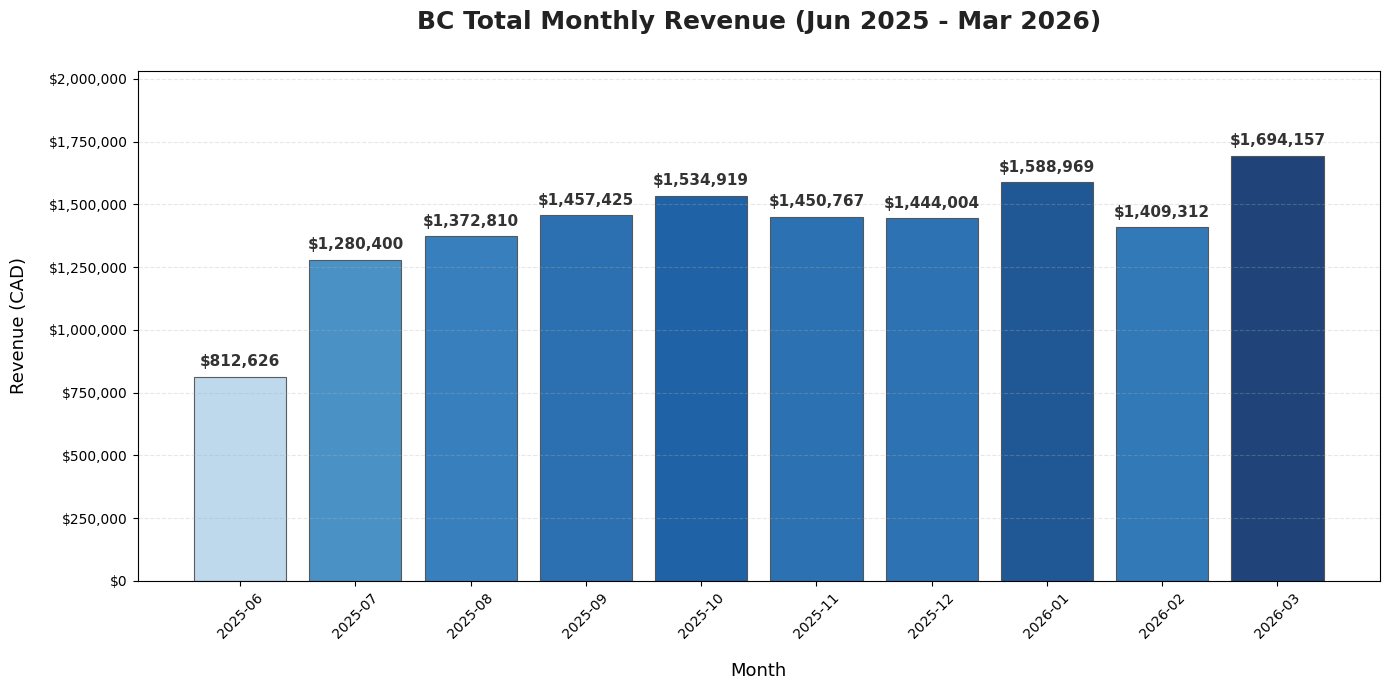

  month_str     Revenue
0   2025-06   812626.39
1   2025-07  1280400.48
2   2025-08  1372810.44
3   2025-09  1457425.23
4   2025-10  1534918.89
5   2025-11  1450766.99
6   2025-12  1444003.69
7   2026-01  1588969.47
8   2026-02  1409311.93
9   2026-03  1694156.97


In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# (이전 데이터 전처리 코드는 동일)
monthly = df_clean[(df_clean['FinalPrice'] > 0) & (df_clean['transaction_date'] < '2026-04-01')].copy()
monthly['month'] = monthly['transaction_date'].dt.to_period('M')

monthly_revenue = monthly.groupby('month')['FinalPrice'].sum().reset_index()
monthly_revenue['month_str'] = monthly_revenue['month'].astype(str)

# --- 시각화 수정 부분 ---
plt.figure(figsize=(14, 7))

# 고급스러운 색상 팔레트 설정
# 매출 금액에 따라 색상 진도를 다르게 함 (매출이 높으면 더 진한 파랑)
revenue_values = monthly_revenue['FinalPrice'].values
normalized_revenue = (revenue_values - revenue_values.min()) / (revenue_values.max() - revenue_values.min())
colors = plt.cm.get_cmap('Blues')(normalized_revenue * 0.7 + 0.3) # 0.3~1.0 범위로 파란색 진도 조정

# 막대 그래프 그리기 (고급스러운 테두리 색상)
bars = plt.bar(monthly_revenue['month_str'], monthly_revenue['FinalPrice'],
               color=colors, edgecolor='#4D4D4D', linewidth=0.8, alpha=0.9)

# 데이터 라벨 (텍스트 크기 및 색상 조정)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 30000, # 여백 조금 더 줌
             f'${height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# 제목 및 라벨
plt.title('BC Total Monthly Revenue (Jun 2025 - Mar 2026)', fontsize=18, pad=30, fontweight='bold', color='#222222')
plt.xlabel('Month', fontsize=13, labelpad=15)
plt.ylabel('Revenue (CAD)', fontsize=13, labelpad=15)
plt.xticks(rotation=45, fontsize=10)

# Y축 포맷팅 ($ 표시 및 최대값 여유)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.ylim(0, monthly_revenue['FinalPrice'].max() * 1.2) # 라벨 공간 확보

# 깔끔한 배경
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(monthly_revenue[['month_str','FinalPrice']].rename(columns={'FinalPrice':'Revenue'}))

## **3-2. 매장별 월별 매출**

In [33]:
# 매장별 월별 매출
store_monthly = df_clean[df_clean['FinalPrice'] > 0].copy()
store_monthly['month'] = store_monthly['transaction_date'].dt.to_period('M')

store_rev = store_monthly.groupby(['month', 'Store_Name'])['FinalPrice'].sum().reset_index()
store_rev['month_str'] = store_rev['month'].astype(str)

# 2026-04 제외 (불완전한 달)
store_rev = store_rev[store_rev['month_str'] != '2026-04']

pivot = store_rev.pivot(index='month_str', columns='Store_Name', values='FinalPrice').fillna(0)
print(pivot.to_string())

Store_Name   Broadway  Coquitlam   Gilmore  KelownaDT  KingGeorge  MarineGate   NorthVan     Robson        UBC      UVic  VictoriaDT
month_str                                                                                                                           
2025-06          0.00        0.0      0.00   84971.05   118161.75   146474.20   76093.92  119022.05  112731.70      0.00   155171.72
2025-07          0.00        0.0      0.00  132451.13   182192.49   218880.28  103110.47  196452.46  189951.91      0.00   257361.74
2025-08          0.00        0.0      0.00  143482.75   202784.94   228832.95  125319.25  212392.02  195973.03      0.00   264025.50
2025-09          0.00        0.0      0.00  144969.57   217638.03   225924.84  126829.78  210444.87  298294.61      0.00   233323.53
2025-10          0.00        0.0      0.00  170508.81   243088.92   228421.92  140223.99  240924.82  286253.16      0.00   225497.27
2025-11          0.00        0.0      0.00  158335.04   233455.04   2